# 4. Orbits and Insolation

A `System` links worlds together gravitationally: a host body (sometimes but not always the star) and one or more worlds orbiting it, each with its own orbital elements. This demo builds a star and a planet, reads the orbital frequency the system computes from the masses and separation, and then computes the starlight the planet receives and the equilibrium temperature that follows, across stellar types and orbital distances.


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import G, au, M_sol, R_sol
from TidalPy.structures_x.system import System
from TidalPy.structures_x.worlds.stellar import StarWorld
from TidalPy.structures_x.configs import build_world

star = StarWorld("Sun", R_sol, M_sol)
star.set_effective_temperature(5772.0)
planet = build_world("earth_simple")

system = System("Star-Planet")
system.add_world(star, is_host=True, is_star=True)
system.add_world(planet, semi_major_axis=au, eccentricity=0.0167)

# A system tracks a world's distance from its tidal *host* and from the *star* separately, because a
# moon can orbit a planet that is not itself the star. Here the star is the host, so the two are equal.
system.set_stellar_semi_major_axis(planet, au)

print("worlds:", [w.name for w in system])
print("host  :", system.host.name, "| star:", system.star.name)


worlds: ['Sun', 'Earth-Simple']
host  : Sun | star: Sun


## Orbital Frequency

Given the two masses and the separation, the system computes the orbital (mean-motion) frequency from Kepler's third law. We check it against the closed-form value and convert it to an orbital period.

In [4]:
n = system.calc_orbital_frequency(planet)
n_kepler = np.sqrt(G * (star.mass + planet.mass) / au**3)
period_days = 2.0 * np.pi / n / 86400.0

print(f"Orbital frequency (system) : {n:.6e} rad/s")
print(f"Orbital frequency (Kepler) : {n_kepler:.6e} rad/s")
print(f"Orbital period             : {period_days:.2f} days  ({period_days/365.25:.3f} yr)")


Orbital frequency (system) : 1.990999e-07 rad/s
Orbital frequency (Kepler) : 1.990999e-07 rad/s
Orbital period             : 365.25 days  (1.000 yr)


## Insolation and Equilibrium Temperature

The star's luminosity sets the flux reaching the planet, which falls off as the inverse square of distance. The planet turns that flux, together with its albedo, into an equilibrium temperature. At 1 au from the Sun this reproduces the solar constant and Earth's roughly 255 K equilibrium temperature.

In [6]:
flux = system.calc_insolation_flux(planet)
t_eq = system.calc_equilibrium_temperature(planet)
print(f"Insolation flux at 1 au    : {flux:.1f} W/m^2  (Solar Constant)")
print(f"Equilibrium temperature    : {t_eq:.1f} K")


Insolation flux at 1 au    : 1361.2 W/m^2  (Solar Constant)
Equilibrium temperature    : 254.6 K


## Stellar Types and Orbital Distances

Five main-sequence types, each with a characteristic effective temperature and radius that together fix its luminosity, traced against the planet's equilibrium temperature as a function of orbital distance. The shaded band marks liquid-water temperatures (273 to 373 K): where it crosses each curve is a rough habitable zone. Hotter, more luminous stars push that zone outward.


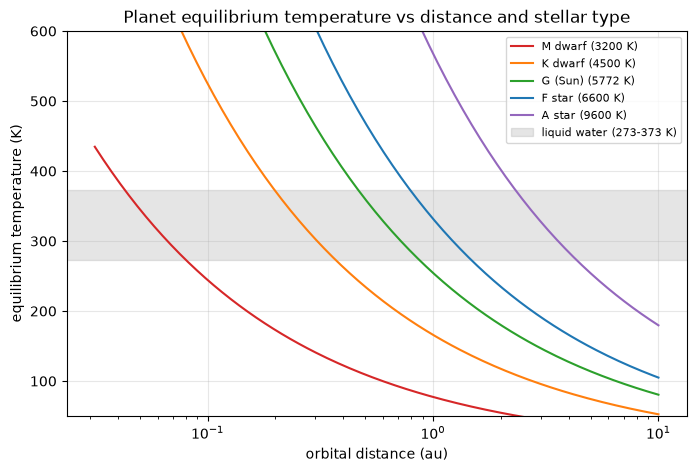

In [7]:
stellar_types = [
    ("M dwarf", 3200.0, 0.30 * R_sol, "tab:red"),
    ("K dwarf", 4500.0, 0.70 * R_sol, "tab:orange"),
    ("G (Sun)", 5772.0, 1.00 * R_sol, "tab:green"),
    ("F star",  6600.0, 1.30 * R_sol, "tab:blue"),
    ("A star",  9600.0, 1.80 * R_sol, "tab:purple"),
]

distances = np.logspace(-1.5, 1.0, 200) * au   # 0.03 to 10 au

fig, ax = plt.subplots(figsize=(8, 5))
for label, teff, radius, color in stellar_types:
    s = StarWorld(label, radius, 1.0e30)
    s.set_effective_temperature(teff)
    flux = s.luminosity / (4.0 * np.pi * distances**2)
    t_eq = np.array([planet.calc_equilibrium_temperature(f) for f in flux])
    ax.plot(distances / au, t_eq, color=color, label=f"{label} ({teff:.0f} K)")

ax.axhspan(273.0, 373.0, color="gray", alpha=0.2, label="liquid water (273-373 K)")
ax.set_xscale("log")
ax.set_xlabel("orbital distance (au)")
ax.set_ylabel("equilibrium temperature (K)")
ax.set_ylim(50, 600)
ax.set_title("Planet equilibrium temperature vs distance and stellar type")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()
